# Mask R-CNN Training Results - Batch 2 - Automatic Extraction
**All data retrieved from maskrcnn_training_batch2 folder**

In [8]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Load All Data from Training Folder

In [9]:
# Paths - Fix directory structure
WORK_DIR = Path('maskrcnn_batch2')
# Find the timestamp directory (like 20260325_074728)
training_dirs = [d for d in WORK_DIR.iterdir() if d.is_dir()]
latest_dir = sorted(training_dirs)[-1]

scalars_file = latest_dir / 'vis_data' / 'scalars.json'
log_files = list(latest_dir.glob('*.log'))
log_file = log_files[0] if log_files else None
config_file = latest_dir / 'vis_data' / 'config.py'

print(f"📂 Training directory: {latest_dir}")
print(f"📄 Scalars file: {scalars_file.exists()}")
print(f"📄 Log file: {log_file.exists() if log_file else 'Not found'}")
print(f"📄 Config file: {config_file.exists()}")

📂 Training directory: maskrcnn_batch2\20260510_084921
📄 Scalars file: True
📄 Log file: True
📄 Config file: True


In [10]:
# Load training data from scalars.json
with open(scalars_file, 'r') as f:
    all_data = [json.loads(line) for line in f]

train_data = [d for d in all_data if 'loss' in d]
train_df = pd.DataFrame(train_data)

print(f"✅ Loaded {len(train_df)} training iterations")
print(f"📊 Epochs: {train_df['epoch'].min()} to {train_df['epoch'].max()}")
print(f"📊 Total iterations: {train_df['step'].max()}")

✅ Loaded 2784 training iterations
📊 Epochs: 1 to 48
📊 Total iterations: 140892


In [11]:
# Extract final validation results from log
with open(log_file, 'r') as f:
    log_content = f.read()
    log_lines = log_content.split('\n')

# Find bbox results
bbox_line = [l for l in log_lines if 'bbox_mAP_copypaste' in l][-1]
bbox_values = bbox_line.split('bbox_mAP_copypaste:')[1].strip().split()
bbox_mAP, bbox_mAP_50, bbox_mAP_75, bbox_mAP_s, bbox_mAP_m, bbox_mAP_l = map(float, bbox_values)

# Find segm results
segm_line = [l for l in log_lines if 'segm_mAP_copypaste' in l][-1]
segm_values = segm_line.split('segm_mAP_copypaste:')[1].strip().split()
segm_mAP, segm_mAP_50, segm_mAP_75, segm_mAP_s, segm_mAP_m, segm_mAP_l = map(float, segm_values)

print("✅ Extracted final results:")
print(f"   bbox mAP: {bbox_mAP:.3f}")
print(f"   segm mAP: {segm_mAP:.3f}")

✅ Extracted final results:
   bbox mAP: 0.720
   segm mAP: 0.686


In [12]:
# Extract class names from config
with open(config_file, 'r') as f:
    config_content = f.read()

# Find classes tuple
import re
classes_match = re.search(r"classes = \(([^)]+)\)", config_content, re.DOTALL)
if classes_match:
    classes_str = classes_match.group(1)
    class_names = [c.strip().strip("'\"") for c in classes_str.split(',') if c.strip()]
    print(f"✅ Extracted {len(class_names)} class names from config")
else:
    class_names = []
    print("⚠️ Could not extract class names")

✅ Extracted 22 class names from config


In [13]:
# Extract validation progress from log
val_epochs = []
for line in log_lines:
    if 'Epoch(val)' in line and 'coco/bbox_mAP:' in line:
        epoch = int(re.search(r'Epoch\(val\) \[(\d+)\]', line).group(1))
        bbox_map = float(re.search(r'coco/bbox_mAP: ([0-9.]+)', line).group(1))
        segm_map = float(re.search(r'coco/segm_mAP: ([0-9.]+)', line).group(1))
        val_epochs.append({'epoch': epoch, 'bbox_mAP': bbox_map, 'segm_mAP': segm_map})

val_df = pd.DataFrame(val_epochs)
print(f"✅ Extracted validation data for {len(val_df)} epochs")

✅ Extracted validation data for 12 epochs


## 2. Training Configuration

In [14]:
# Extract training info
num_epochs = int(train_df['epoch'].max())
total_iters = int(train_df['step'].max())
initial_lr = float(train_df['lr'].iloc[0])
final_lr = float(train_df['lr'].iloc[-1])
num_classes = len(class_names)

# Extract batch size and other info from config
batch_size = int(re.search(r'batch_size=(\d+)', config_content).group(1))
max_epochs = int(re.search(r'max_epochs=(\d+)', config_content).group(1))

config_table = pd.DataFrame({
    'Parameter': ['Epochs', 'Total Iterations', 'Classes', 'Batch Size', 'Initial LR', 'Final LR'],
    'Value': [num_epochs, total_iters, num_classes, batch_size, f"{initial_lr:.6f}", f"{final_lr:.6f}"]
})

print("="*60)
print("TRAINING CONFIGURATION")
print("="*60)
print(config_table.to_string(index=False))

TRAINING CONFIGURATION
       Parameter    Value
          Epochs       48
Total Iterations   140892
         Classes       22
      Batch Size       16
      Initial LR 0.001000
        Final LR 0.000200


## 3. Class Names

In [15]:
print(f"Total Classes: {len(class_names)}\n")
for i, name in enumerate(class_names):
    print(f"{i:2d}: {name}")

Total Classes: 22

 0: carros
 1: Back-bumper
 2: Back-door
 3: Back-wheel
 4: Back-window
 5: Back-windshield
 6: Fender
 7: Front-bumper
 8: Front-door
 9: Front-wheel
10: Front-window
11: Grille
12: Headlight
13: Hood
14: License-plate
15: Mirror
16: Quarter-panel
17: Rocker-panel
18: Roof
19: Tail-light
20: Trunk
21: Windshield


## 4. Final Performance Results

In [16]:
# BBox results
bbox_df = pd.DataFrame({
    'Metric': ['mAP', 'mAP@50', 'mAP@75', 'mAP (small)', 'mAP (medium)', 'mAP (large)'],
    'Value': [bbox_mAP, bbox_mAP_50, bbox_mAP_75, bbox_mAP_s, bbox_mAP_m, bbox_mAP_l],
    'Percentage': [f"{v*100:.1f}%" for v in [bbox_mAP, bbox_mAP_50, bbox_mAP_75, bbox_mAP_s, bbox_mAP_m, bbox_mAP_l]]
})

# Segm results
segm_df = pd.DataFrame({
    'Metric': ['mAP', 'mAP@50', 'mAP@75', 'mAP (small)', 'mAP (medium)', 'mAP (large)'],
    'Value': [segm_mAP, segm_mAP_50, segm_mAP_75, segm_mAP_s, segm_mAP_m, segm_mAP_l],
    'Percentage': [f"{v*100:.1f}%" for v in [segm_mAP, segm_mAP_50, segm_mAP_75, segm_mAP_s, segm_mAP_m, segm_mAP_l]]
})

print("="*60)
print("BBOX DETECTION RESULTS")
print("="*60)
print(bbox_df[['Metric', 'Percentage']].to_string(index=False))

print("\n" + "="*60)
print("INSTANCE SEGMENTATION RESULTS")
print("="*60)
print(segm_df[['Metric', 'Percentage']].to_string(index=False))

BBOX DETECTION RESULTS
      Metric Percentage
         mAP      72.0%
      mAP@50      92.2%
      mAP@75      80.1%
 mAP (small)      32.6%
mAP (medium)      63.3%
 mAP (large)      79.0%

INSTANCE SEGMENTATION RESULTS
      Metric Percentage
         mAP      68.6%
      mAP@50      90.0%
      mAP@75      75.6%
 mAP (small)      20.4%
mAP (medium)      57.2%
 mAP (large)      77.9%


## 5. Performance Visualization

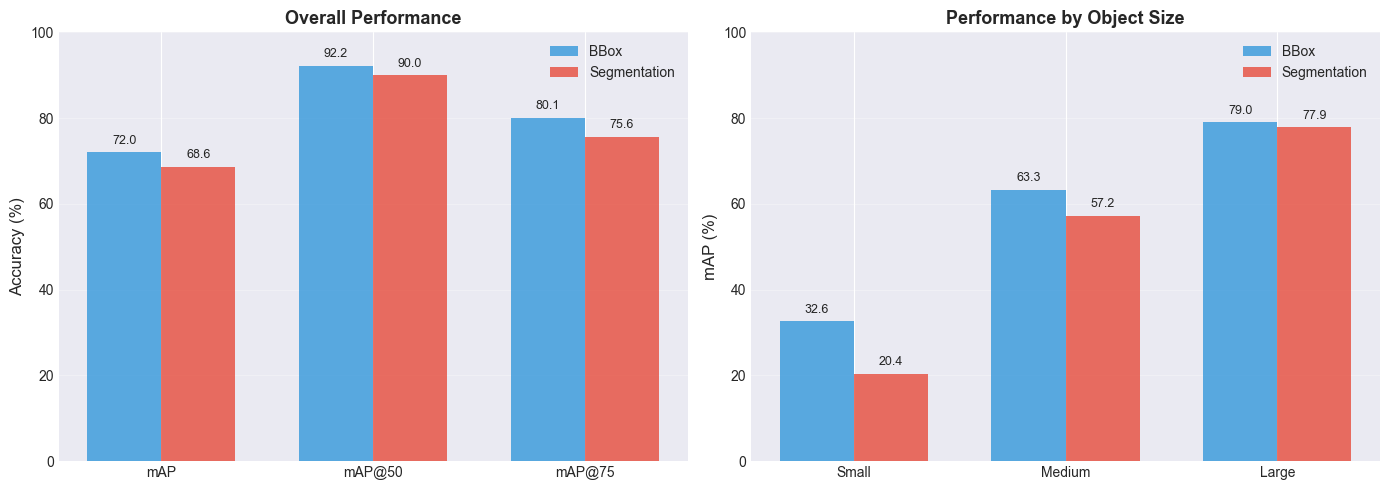

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall performance
metrics = ['mAP', 'mAP@50', 'mAP@75']
bbox_vals = [bbox_mAP*100, bbox_mAP_50*100, bbox_mAP_75*100]
segm_vals = [segm_mAP*100, segm_mAP_50*100, segm_mAP_75*100]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, bbox_vals, width, label='BBox', color='#3498db', alpha=0.8)
axes[0].bar(x + width/2, segm_vals, width, label='Segmentation', color='#e74c3c', alpha=0.8)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Overall Performance', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 100)

for i, (b, s) in enumerate(zip(bbox_vals, segm_vals)):
    axes[0].text(i - width/2, b + 2, f'{b:.1f}', ha='center', fontsize=9)
    axes[0].text(i + width/2, s + 2, f'{s:.1f}', ha='center', fontsize=9)

# By object size
sizes = ['Small', 'Medium', 'Large']
bbox_size = [bbox_mAP_s*100, bbox_mAP_m*100, bbox_mAP_l*100]
segm_size = [segm_mAP_s*100, segm_mAP_m*100, segm_mAP_l*100]

x2 = np.arange(len(sizes))
axes[1].bar(x2 - width/2, bbox_size, width, label='BBox', color='#3498db', alpha=0.8)
axes[1].bar(x2 + width/2, segm_size, width, label='Segmentation', color='#e74c3c', alpha=0.8)
axes[1].set_ylabel('mAP (%)', fontsize=12)
axes[1].set_title('Performance by Object Size', fontsize=13, fontweight='bold')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(sizes)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, 100)

for i, (b, s) in enumerate(zip(bbox_size, segm_size)):
    axes[1].text(i - width/2, b + 2, f'{b:.1f}', ha='center', fontsize=9)
    axes[1].text(i + width/2, s + 2, f'{s:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Training Loss Curves

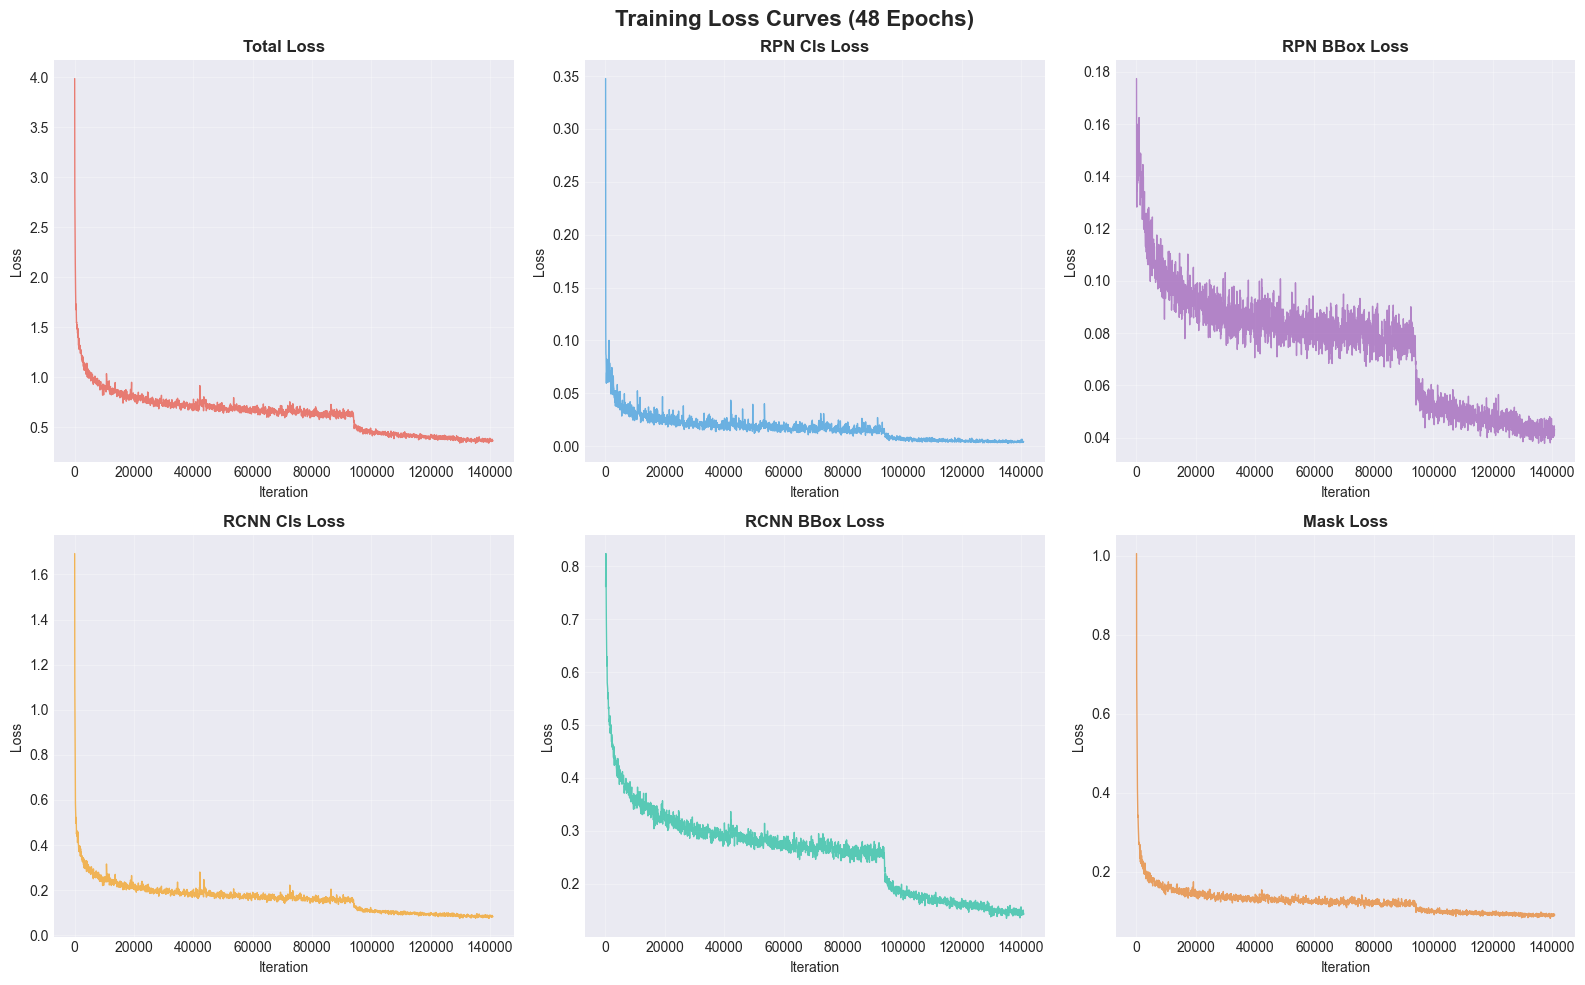

Final Losses (Epoch 48, Iter 140892):
  Total: 0.3649
  RPN Cls: 0.0042
  RPN BBox: 0.0431
  RCNN Cls: 0.0830
  RCNN BBox: 0.1435
  Mask: 0.0912
  Accuracy: 96.19%


In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(f'Training Loss Curves ({num_epochs} Epochs)', fontsize=16, fontweight='bold')

axes[0, 0].plot(train_df['step'], train_df['loss'], color='#e74c3c', linewidth=1, alpha=0.7)
axes[0, 0].set_title('Total Loss', fontweight='bold')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(train_df['step'], train_df['loss_rpn_cls'], color='#3498db', linewidth=1, alpha=0.7)
axes[0, 1].set_title('RPN Cls Loss', fontweight='bold')
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].grid(alpha=0.3)

axes[0, 2].plot(train_df['step'], train_df['loss_rpn_bbox'], color='#9b59b6', linewidth=1, alpha=0.7)
axes[0, 2].set_title('RPN BBox Loss', fontweight='bold')
axes[0, 2].set_xlabel('Iteration')
axes[0, 2].set_ylabel('Loss')
axes[0, 2].grid(alpha=0.3)

axes[1, 0].plot(train_df['step'], train_df['loss_cls'], color='#f39c12', linewidth=1, alpha=0.7)
axes[1, 0].set_title('RCNN Cls Loss', fontweight='bold')
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(train_df['step'], train_df['loss_bbox'], color='#1abc9c', linewidth=1, alpha=0.7)
axes[1, 1].set_title('RCNN BBox Loss', fontweight='bold')
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].grid(alpha=0.3)

axes[1, 2].plot(train_df['step'], train_df['loss_mask'], color='#e67e22', linewidth=1, alpha=0.7)
axes[1, 2].set_title('Mask Loss', fontweight='bold')
axes[1, 2].set_xlabel('Iteration')
axes[1, 2].set_ylabel('Loss')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Show final losses
final_row = train_df.iloc[-1]
print(f"Final Losses (Epoch {int(final_row['epoch'])}, Iter {int(final_row['step'])}):")
print(f"  Total: {final_row['loss']:.4f}")
print(f"  RPN Cls: {final_row['loss_rpn_cls']:.4f}")
print(f"  RPN BBox: {final_row['loss_rpn_bbox']:.4f}")
print(f"  RCNN Cls: {final_row['loss_cls']:.4f}")
print(f"  RCNN BBox: {final_row['loss_bbox']:.4f}")
print(f"  Mask: {final_row['loss_mask']:.4f}")
print(f"  Accuracy: {final_row['acc']:.2f}%")

## 7. Learning Rate Schedule

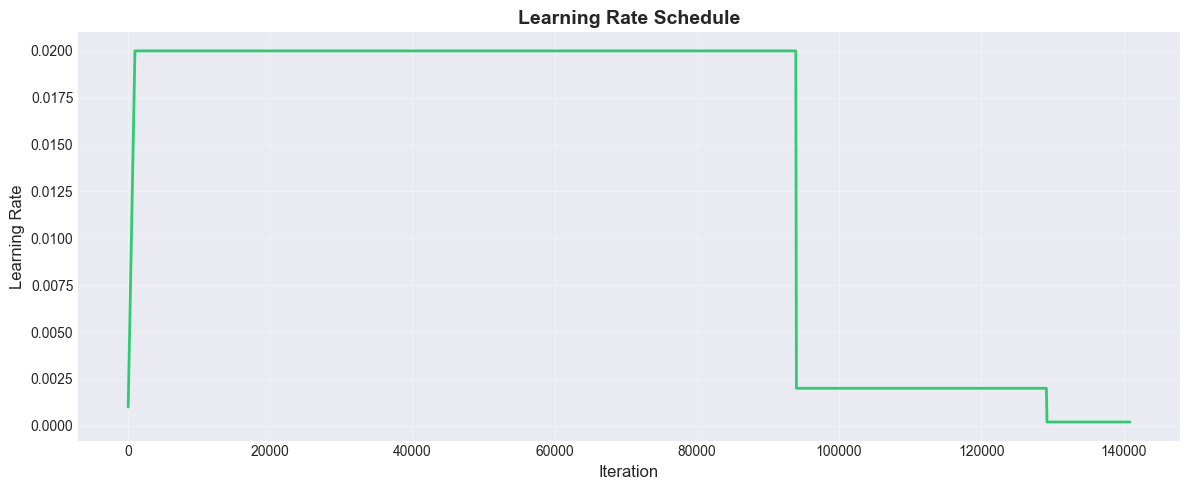

Initial LR: 0.001000
Final LR: 0.000200


In [19]:
plt.figure(figsize=(12, 5))
plt.plot(train_df['step'], train_df['lr'], color='#2ecc71', linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Learning Rate', fontsize=12)
plt.title('Learning Rate Schedule', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial LR: {initial_lr:.6f}")
print(f"Final LR: {final_lr:.6f}")

## 8. Validation Progress

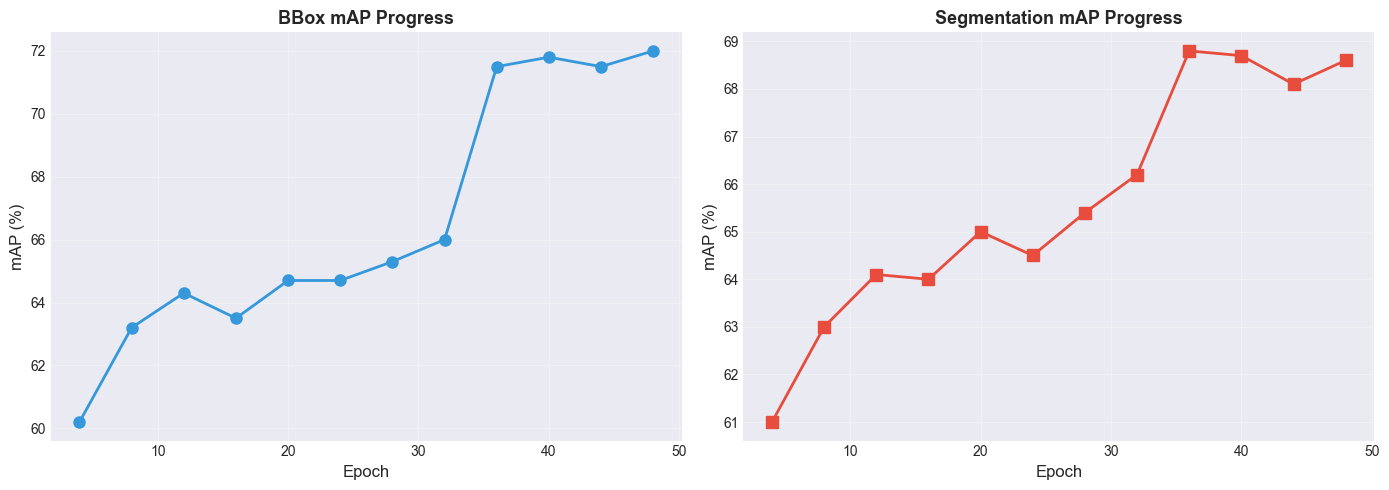


Validation Progress:
 epoch bbox_mAP segm_mAP
     4    60.2%    61.0%
     8    63.2%    63.0%
    12    64.3%    64.1%
    16    63.5%    64.0%
    20    64.7%    65.0%
    24    64.7%    64.5%
    28    65.3%    65.4%
    32    66.0%    66.2%
    36    71.5%    68.8%
    40    71.8%    68.7%
    44    71.5%    68.1%
    48    72.0%    68.6%


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(val_df['epoch'], val_df['bbox_mAP']*100, marker='o', linewidth=2, markersize=8, color='#3498db')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('mAP (%)', fontsize=12)
axes[0].set_title('BBox mAP Progress', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(val_df['epoch'], val_df['segm_mAP']*100, marker='s', linewidth=2, markersize=8, color='#e74c3c')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('mAP (%)', fontsize=12)
axes[1].set_title('Segmentation mAP Progress', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Show validation table
val_display = val_df.copy()
val_display['bbox_mAP'] = val_display['bbox_mAP'].apply(lambda x: f"{x*100:.1f}%")
val_display['segm_mAP'] = val_display['segm_mAP'].apply(lambda x: f"{x*100:.1f}%")
print("\nValidation Progress:")
print(val_display.to_string(index=False))

## 9. Summary Statistics

In [21]:
print("="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"Epochs Trained: {num_epochs}")
print(f"Total Iterations: {total_iters:,}")
print(f"Classes: {num_classes}")
print(f"Final Classification Accuracy: {final_row['acc']:.2f}%")
print(f"\nBBox mAP: {bbox_mAP*100:.1f}%")
print(f"Segmentation mAP: {segm_mAP*100:.1f}%")
print(f"Gap (bbox - segm): {(bbox_mAP - segm_mAP)*100:.1f} pp")

TRAINING SUMMARY
Epochs Trained: 48
Total Iterations: 140,892
Classes: 22
Final Classification Accuracy: 96.19%

BBox mAP: 72.0%
Segmentation mAP: 68.6%
Gap (bbox - segm): 3.4 pp


## 10. Export Results

In [22]:
# Create results directory
results_dir = Path('results_batch2')
results_dir.mkdir(exist_ok=True)

# Export summary table
summary = pd.DataFrame({
    'Method': ['Mask R-CNN Batch 2'],
    'bbox_mAP': [f"{bbox_mAP*100:.1f}"],
    'bbox_mAP_50': [f"{bbox_mAP_50*100:.1f}"],
    'bbox_mAP_75': [f"{bbox_mAP_75*100:.1f}"],
    'segm_mAP': [f"{segm_mAP*100:.1f}"],
    'segm_mAP_50': [f"{segm_mAP_50*100:.1f}"],
    'segm_mAP_75': [f"{segm_mAP_75*100:.1f}"]
})

summary.to_csv(results_dir / 'maskrcnn_batch2_summary.csv', index=False)
bbox_df.to_csv(results_dir / 'maskrcnn_batch2_bbox.csv', index=False)
segm_df.to_csv(results_dir / 'maskrcnn_batch2_segm.csv', index=False)
val_df.to_csv(results_dir / 'maskrcnn_batch2_validation.csv', index=False)

print("✅ Results exported to:")
print(f"   - {results_dir / 'maskrcnn_batch2_summary.csv'}")
print(f"   - {results_dir / 'maskrcnn_batch2_bbox.csv'}")
print(f"   - {results_dir / 'maskrcnn_batch2_segm.csv'}")
print(f"   - {results_dir / 'maskrcnn_batch2_validation.csv'}")

✅ Results exported to:
   - results_batch2\maskrcnn_batch2_summary.csv
   - results_batch2\maskrcnn_batch2_bbox.csv
   - results_batch2\maskrcnn_batch2_segm.csv
   - results_batch2\maskrcnn_batch2_validation.csv


---
**All data automatically extracted from:** `maskrcnn_training_batch2/maskrcnn/`